# DiscountMate: leakage-safe additional features and purchase-probability model

This notebook turns the REES46 events into user-product snapshots, predicts whether a product will be purchased in the **next 3 days**, and evaluates the result as both a probability model and a Top-10 recommender.

Important design rule: features only use events strictly before each cutoff. Future purchase events are used only to create `label`. Model selection uses validation data; the test set is evaluated once at the end.

## Section 1 — Build additional features

Each snapshot uses a 7-day history. A user-product pair becomes a candidate when it has at least one event in the final 2 days of that history, which mirrors online scoring from recent events. The target is any purchase of that pair in the following 3 days. Three historical snapshots form training data; later, disjoint snapshots form validation and test data.

In [1]:
from pathlib import Path
from datetime import datetime, timedelta, timezone
import json
import os
import platform
import time
import warnings

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    raise FileNotFoundError("Run this notebook from the DiscountMate project root (the folder containing data/).")

# Keep plotting caches inside the project so the notebook also works in restricted environments.
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib_cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import sklearn

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss, classification_report,
    confusion_matrix, log_loss, precision_recall_curve, PrecisionRecallDisplay,
    RocCurveDisplay, roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

DATA_DIR = ROOT / "data"
RAW_FILES = [DATA_DIR / "train.parquet", DATA_DIR / "validation.parquet", DATA_DIR / "test.parquet"]
OUTPUT_DIR = DATA_DIR / "Additional_Features"
MODEL_DIR = ROOT / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for path in RAW_FILES:
    if not path.exists():
        raise FileNotFoundError(path)

print(f"Python {platform.python_version()} | Polars {pl.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")
print("Input:", DATA_DIR)
print("Feature output:", OUTPUT_DIR)
print("Model output:", MODEL_DIR)

Python 3.11.14 | Polars 1.40.1 | pandas 3.0.0 | scikit-learn 1.8.0
Input: /Users/ethan/Desktop/Applied_AI/2026_T2/SIT782/DiscountMate/data
Feature output: /Users/ethan/Desktop/Applied_AI/2026_T2/SIT782/DiscountMate/data/Additional_Features
Model output: /Users/ethan/Desktop/Applied_AI/2026_T2/SIT782/DiscountMate/models


In [2]:
# Set True after changing the feature logic. Existing valid outputs are reused by default.
REBUILD_FEATURES = False
LOOKBACK_DAYS = 7
CANDIDATE_DAYS = 2
HORIZON_DAYS = 3

def utc_date(year, month, day):
    return datetime(year, month, day, tzinfo=timezone.utc)

SNAPSHOTS = {
    "train": [utc_date(2019, 10, 8), utc_date(2019, 10, 13), utc_date(2019, 10, 19)],
    "validation": [utc_date(2019, 10, 24)],
    "test": [utc_date(2019, 10, 29)],
}

FEATURE_FILES = {
    split: OUTPUT_DIR / f"DiscountMATE_REES46_{split}_additional_features.parquet"
    for split in SNAPSHOTS
}

events = pl.concat(
    [
        pl.scan_parquet(path).select(
            pl.col("event_time"),
            pl.col("event_type").cast(pl.String),
            pl.col("product_id").cast(pl.Int64),
            pl.col("category_id").cast(pl.Int64),
            pl.col("category_code").cast(pl.String),
            pl.col("brand").cast(pl.String),
            pl.col("price").cast(pl.Float32),
            pl.col("user_id").cast(pl.Int64),
            pl.col("user_session").cast(pl.String),
        )
        for path in RAW_FILES
    ],
    how="vertical_relaxed",
).filter(pl.col("user_id").is_not_null() & pl.col("product_id").is_not_null())

print("Snapshot plan:")
for split, cutoffs in SNAPSHOTS.items():
    for cutoff in cutoffs:
        print(
            f"  {split:10s} history [{(cutoff-timedelta(days=LOOKBACK_DAYS)).date()}, {cutoff.date()}) "
            f"candidate since {(cutoff-timedelta(days=CANDIDATE_DAYS)).date()} -> "
            f"label [{cutoff.date()}, {(cutoff+timedelta(days=HORIZON_DAYS)).date()})"
        )

Snapshot plan:
  train      history [2019-10-01, 2019-10-08) candidate since 2019-10-06 -> label [2019-10-08, 2019-10-11)
  train      history [2019-10-06, 2019-10-13) candidate since 2019-10-11 -> label [2019-10-13, 2019-10-16)
  train      history [2019-10-12, 2019-10-19) candidate since 2019-10-17 -> label [2019-10-19, 2019-10-22)
  validation history [2019-10-17, 2019-10-24) candidate since 2019-10-22 -> label [2019-10-24, 2019-10-27)
  test       history [2019-10-22, 2019-10-29) candidate since 2019-10-27 -> label [2019-10-29, 2019-11-01)


In [3]:
def _event_count(event_name, alias):
    return (pl.col("event_type") == event_name).sum().cast(pl.UInt32).alias(alias)

def _last_event(event_name, alias):
    return pl.col("event_time").filter(pl.col("event_type") == event_name).max().alias(alias)

def _recency(column, alias, cutoff):
    return (
        (pl.lit(cutoff) - pl.col(column)).dt.total_seconds() / 86_400
    ).cast(pl.Float32).fill_null(LOOKBACK_DAYS + 1).alias(alias)

def build_snapshot(cutoff):
    history_start = cutoff - timedelta(days=LOOKBACK_DAYS)
    candidate_start = cutoff - timedelta(days=CANDIDATE_DAYS)
    future_end = cutoff + timedelta(days=HORIZON_DAYS)

    # Materialise one bounded history window; all aggregations below reuse it.
    history = (
        events.filter((pl.col("event_time") >= history_start) & (pl.col("event_time") < cutoff))
        .collect(engine="streaming")
    )
    h = history.lazy()

    candidates = (
        h.filter(pl.col("event_time") >= candidate_start)
        .select("user_id", "product_id")
        .unique()
    )

    pair = h.group_by("user_id", "product_id").agg(
        pl.len().cast(pl.UInt32).alias("pair_total_events"),
        _event_count("view", "view_count"),
        _event_count("cart", "cart_count"),
        _event_count("purchase", "past_purchase_count"),
        pl.col("user_session").n_unique().cast(pl.UInt32).alias("session_count"),
        pl.col("event_time").dt.date().n_unique().cast(pl.UInt8).alias("pair_active_days"),
        pl.col("price").mean().cast(pl.Float32).alias("pair_avg_price"),
        pl.col("price").std().fill_null(0).cast(pl.Float32).alias("pair_price_std"),
        pl.col("price").sort_by("event_time").drop_nulls().last().cast(pl.Float32).alias("price"),
        pl.col("category_id").sort_by("event_time").drop_nulls().last().alias("category_id"),
        pl.col("brand").sort_by("event_time").drop_nulls().last().alias("_brand"),
        pl.col("event_time").min().alias("_first_event"),
        pl.col("event_time").max().alias("_last_event"),
        _last_event("view", "_last_view"),
        _last_event("cart", "_last_cart"),
        _last_event("purchase", "_last_purchase"),
        pl.col("event_time").sort().last().dt.hour().cast(pl.UInt8).alias("last_event_hour"),
        pl.col("event_time").sort().last().dt.weekday().cast(pl.UInt8).alias("last_event_weekday"),
    )

    user = h.group_by("user_id").agg(
        pl.len().cast(pl.UInt32).alias("user_total_events"),
        _event_count("view", "user_total_views"),
        _event_count("cart", "user_total_carts"),
        _event_count("purchase", "user_total_purchases"),
        pl.col("product_id").n_unique().cast(pl.UInt32).alias("user_unique_products"),
        pl.col("user_session").n_unique().cast(pl.UInt32).alias("user_session_count"),
        pl.col("event_time").dt.date().n_unique().cast(pl.UInt8).alias("user_active_days"),
        pl.col("price").mean().cast(pl.Float32).alias("user_avg_price"),
        pl.col("event_time").max().alias("_user_last_event"),
    )

    product = h.group_by("product_id").agg(
        pl.len().cast(pl.UInt32).alias("product_total_events"),
        _event_count("view", "product_total_views"),
        _event_count("cart", "product_total_carts"),
        _event_count("purchase", "product_total_purchases"),
        pl.col("user_id").n_unique().cast(pl.UInt32).alias("product_unique_users"),
        pl.col("user_session").n_unique().cast(pl.UInt32).alias("product_session_count"),
        pl.col("price").mean().cast(pl.Float32).alias("product_avg_price"),
        pl.col("event_time").max().alias("_product_last_event"),
    )

    category = h.filter(pl.col("category_id").is_not_null()).group_by("category_id").agg(
        _event_count("view", "category_total_views"),
        _event_count("cart", "category_total_carts"),
        _event_count("purchase", "category_total_purchases"),
        pl.col("user_id").n_unique().cast(pl.UInt32).alias("category_unique_users"),
        pl.col("product_id").n_unique().cast(pl.UInt32).alias("category_unique_products"),
    )

    brand = h.filter(pl.col("brand").is_not_null()).group_by("brand").agg(
        _event_count("view", "brand_total_views"),
        _event_count("cart", "brand_total_carts"),
        _event_count("purchase", "brand_total_purchases"),
        pl.col("user_id").n_unique().cast(pl.UInt32).alias("brand_unique_users"),
    ).rename({"brand": "_brand"})

    labels = (
        events.filter(
            (pl.col("event_time") >= cutoff)
            & (pl.col("event_time") < future_end)
            & (pl.col("event_type") == "purchase")
        )
        .group_by("user_id", "product_id")
        .agg(pl.len().cast(pl.UInt16).alias("_future_purchase_count"))
    )

    result = (
        candidates.join(pair, on=["user_id", "product_id"], how="left")
        .join(user, on="user_id", how="left")
        .join(product, on="product_id", how="left")
        .join(category, on="category_id", how="left")
        .join(brand, on="_brand", how="left")
        .join(labels, on=["user_id", "product_id"], how="left")
        .with_columns(
            pl.lit(cutoff.date().isoformat()).alias("snapshot_date"),
            pl.col("_future_purchase_count").fill_null(0).gt(0).cast(pl.Int8).alias("label"),
            _recency("_last_event", "days_since_last_event", cutoff),
            _recency("_last_view", "days_since_last_view", cutoff),
            _recency("_last_cart", "days_since_last_cart", cutoff),
            _recency("_last_purchase", "days_since_last_purchase", cutoff),
            _recency("_first_event", "days_since_first_event", cutoff),
            _recency("_user_last_event", "user_days_since_last_event", cutoff),
            _recency("_product_last_event", "product_days_since_last_event", cutoff),
        )
        .with_columns(
            (pl.col("cart_count") / (pl.col("view_count") + 1)).cast(pl.Float32).alias("pair_view_to_cart_rate"),
            (pl.col("past_purchase_count") / (pl.col("cart_count") + 1)).cast(pl.Float32).alias("pair_cart_to_purchase_rate"),
            (pl.col("user_total_carts") / (pl.col("user_total_views") + 1)).cast(pl.Float32).alias("user_cart_rate"),
            (pl.col("user_total_purchases") / (pl.col("user_total_views") + 1)).cast(pl.Float32).alias("user_purchase_rate"),
            (pl.col("product_total_carts") / (pl.col("product_total_views") + 1)).cast(pl.Float32).alias("product_cart_rate"),
            (pl.col("product_total_purchases") / (pl.col("product_total_views") + 1)).cast(pl.Float32).alias("product_purchase_rate"),
            (pl.col("category_total_purchases") / (pl.col("category_total_views") + 1)).cast(pl.Float32).alias("category_purchase_rate"),
            (pl.col("brand_total_purchases") / (pl.col("brand_total_views") + 1)).cast(pl.Float32).alias("brand_purchase_rate"),
            (pl.col("view_count") / (pl.col("user_total_views") + 1)).cast(pl.Float32).alias("pair_share_of_user_views"),
            (pl.col("view_count") / (pl.col("product_total_views") + 1)).cast(pl.Float32).alias("pair_share_of_product_views"),
            (pl.col("price") / (pl.col("user_avg_price") + 0.01)).cast(pl.Float32).alias("price_to_user_avg"),
            (pl.col("price") / (pl.col("product_avg_price") + 0.01)).cast(pl.Float32).alias("price_to_product_avg"),
            (pl.col("pair_total_events") / pl.col("pair_active_days").clip(lower_bound=1)).cast(pl.Float32).alias("pair_events_per_active_day"),
        )
        .drop(
            "_brand", "_future_purchase_count", "_first_event", "_last_event", "_last_view",
            "_last_cart", "_last_purchase", "_user_last_event", "_product_last_event",
        )
        .fill_null(0)
        .collect(engine="streaming")
    )
    return result

print("Feature builder ready.")

Feature builder ready.


In [4]:
required_columns = {
    "user_id", "product_id", "snapshot_date", "days_since_last_view",
    "days_since_last_cart", "session_count", "user_total_views",
    "user_unique_products", "product_total_carts", "price", "label",
}

def feature_outputs_are_valid():
    if not all(path.exists() for path in FEATURE_FILES.values()):
        return False
    return all(
        required_columns.issubset(set(pl.scan_parquet(path).collect_schema().names()))
        for path in FEATURE_FILES.values()
    )

if REBUILD_FEATURES or not feature_outputs_are_valid():
    started = time.perf_counter()
    for split, cutoffs in SNAPSHOTS.items():
        frames = []
        for cutoff in cutoffs:
            t0 = time.perf_counter()
            frame = build_snapshot(cutoff)
            frames.append(frame)
            print(
                f"{split:10s} {cutoff.date()}: {frame.height:,} rows, "
                f"{frame['label'].sum():,} positives, {time.perf_counter()-t0:.1f}s"
            )
        output = pl.concat(frames, how="vertical_relaxed")
        output.write_parquet(FEATURE_FILES[split], compression="zstd", statistics=True)
        print(f"Wrote {FEATURE_FILES[split]} ({FEATURE_FILES[split].stat().st_size/1024**2:.1f} MiB)")
        del frames, output
    print(f"All feature files built in {(time.perf_counter()-started)/60:.1f} minutes.")
else:
    print("Reusing existing feature files. Set REBUILD_FEATURES=True to regenerate them.")

Reusing existing feature files. Set REBUILD_FEATURES=True to regenerate them.


In [5]:
def future_purchase_ground_truth(cutoffs):
    frames = []
    for cutoff in cutoffs:
        frames.append(
            events.filter(
                (pl.col("event_time") >= cutoff)
                & (pl.col("event_time") < cutoff + timedelta(days=HORIZON_DAYS))
                & (pl.col("event_type") == "purchase")
            )
            .select("user_id", "product_id")
            .unique()
            .with_columns(pl.lit(cutoff.date().isoformat()).alias("snapshot_date"))
            .collect(engine="streaming")
        )
    return pl.concat(frames, how="vertical_relaxed")

feature_summary = []
GROUND_TRUTH = {}
for split, feature_path in FEATURE_FILES.items():
    frame = pl.scan_parquet(feature_path)
    ground_truth = future_purchase_ground_truth(SNAPSHOTS[split])
    GROUND_TRUTH[split] = ground_truth

    summary = (
        frame.select(
            pl.len().alias("rows"),
            pl.col("label").sum().alias("candidate_positives"),
            pl.col("user_id").n_unique().alias("scored_users"),
            pl.col("product_id").n_unique().alias("products"),
        )
        .collect()
        .with_columns(
            pl.lit(split).alias("split"),
            pl.lit(ground_truth.height).alias("all_future_purchase_pairs"),
            pl.lit(
                ground_truth.select(pl.struct("snapshot_date", "user_id").n_unique()).item()
            ).alias("all_future_purchase_users"),
        )
        .with_columns(
            (pl.col("candidate_positives") / pl.col("rows")).alias("positive_rate"),
            (pl.col("candidate_positives") / pl.col("all_future_purchase_pairs")).alias("candidate_pair_coverage"),
        )
    )
    feature_summary.append(summary)

feature_summary = pl.concat(feature_summary).select(
    "split", "rows", "candidate_positives", "positive_rate", "scored_users", "products",
    "all_future_purchase_pairs", "all_future_purchase_users", "candidate_pair_coverage",
)
display(feature_summary.to_pandas())

schema = pl.scan_parquet(FEATURE_FILES["train"]).collect_schema()
print(f"{len(schema)} output columns:")
print(schema.names())

manifest = {
    "lookback_days": LOOKBACK_DAYS,
    "candidate_days": CANDIDATE_DAYS,
    "label_horizon_days": HORIZON_DAYS,
    "snapshots": {k: [d.isoformat() for d in v] for k, v in SNAPSHOTS.items()},
    "files": {k: str(v.relative_to(ROOT)) for k, v in FEATURE_FILES.items()},
    "columns": schema.names(),
    "candidate_definition": "user-product pair with >=1 event in the final 2 history days",
    "coverage_warning": "Ranking cannot recover a future purchase pair absent from the candidate set.",
}
_ = (OUTPUT_DIR / "feature_manifest.json").write_text(
    json.dumps(manifest, indent=2), encoding="utf-8"
)

,split,rows,candidate_positives,positive_rate,scored_users,products,all_future_purchase_pairs,all_future_purchase_users,candidate_pair_coverage
0,train,5087659,23390,0.004597,965228,127123,189057,147434,0.123719
1,validation,1687123,7167,0.004248,404605,95938,59254,46432,0.120954
2,test,1599511,6033,0.003772,362467,94877,51509,40588,0.117125


60 output columns:
['user_id', 'product_id', 'pair_total_events', 'view_count', 'cart_count', 'past_purchase_count', 'session_count', 'pair_active_days', 'pair_avg_price', 'pair_price_std', 'price', 'category_id', 'last_event_hour', 'last_event_weekday', 'user_total_events', 'user_total_views', 'user_total_carts', 'user_total_purchases', 'user_unique_products', 'user_session_count', 'user_active_days', 'user_avg_price', 'product_total_events', 'product_total_views', 'product_total_carts', 'product_total_purchases', 'product_unique_users', 'product_session_count', 'product_avg_price', 'category_total_views', 'category_total_carts', 'category_total_purchases', 'category_unique_users', 'category_unique_products', 'brand_total_views', 'brand_total_carts', 'brand_total_purchases', 'brand_unique_users', 'snapshot_date', 'label', 'days_since_last_event', 'days_since_last_view', 'days_since_last_cart', 'days_since_last_purchase', 'days_since_first_event', 'user_days_since_last_event', 'product

## Section 2 — Train, validate, select, calibrate, and export

The full validation set remains chronologically later than every training snapshot. To control memory, training keeps every positive and a reproducible sample of negatives; negative sample weights restore the original class prior. We compare a linear probability baseline with two histogram gradient-boosting configurations. The winner is selected by validation **NDCG@10** (then PR-AUC), because the deployment goal is a ranked homepage. Validation is then used for sigmoid probability calibration and for choosing one optional classification threshold. Top-10 recommendation itself uses probability order and needs no threshold.

In [6]:
ID_COLUMNS = ["user_id", "product_id", "category_id", "snapshot_date"]
TARGET = "label"
all_columns = pl.scan_parquet(FEATURE_FILES["train"]).collect_schema().names()
FEATURE_COLUMNS = [c for c in all_columns if c not in ID_COLUMNS + [TARGET]]

# All positives plus at most 10 negatives per positive (capped) gives a scalable, weighted training set.
train_lazy = pl.scan_parquet(FEATURE_FILES["train"]).select(FEATURE_COLUMNS + [TARGET])
counts = train_lazy.group_by(TARGET).len().collect().sort(TARGET)
n_positive = int(counts.filter(pl.col(TARGET) == 1)["len"].item())
n_negative = int(counts.filter(pl.col(TARGET) == 0)["len"].item())
n_negative_sample = min(n_negative, max(250_000, 10 * n_positive), 1_500_000)
negative_weight = n_negative / n_negative_sample

positive_train = train_lazy.filter(pl.col(TARGET) == 1).collect()
negative_train = (
    train_lazy.filter(pl.col(TARGET) == 0)
    .collect()
    .sample(n=n_negative_sample, seed=RANDOM_STATE, shuffle=True)
)
sampled_train = pl.concat([positive_train, negative_train], how="vertical_relaxed").sample(
    fraction=1.0, seed=RANDOM_STATE, shuffle=True
)
train_weights = np.where(sampled_train[TARGET].to_numpy() == 0, negative_weight, 1.0)
X_train = sampled_train.select(FEATURE_COLUMNS).to_pandas()
y_train = sampled_train[TARGET].to_numpy()

validation_frame = pl.read_parquet(FEATURE_FILES["validation"])
X_validation = validation_frame.select(FEATURE_COLUMNS).to_pandas()
y_validation = validation_frame[TARGET].to_numpy()

print(f"Features: {len(FEATURE_COLUMNS)}")
print(f"Full train: {n_positive+n_negative:,} ({n_positive:,} positive); fitted sample: {len(y_train):,}")
print(f"Negative sample weight: {negative_weight:.3f}")
print(f"Validation: {len(y_validation):,} rows ({y_validation.sum():,} positive)")

Features: 55
Full train: 5,087,659 (23,390 positive); fitted sample: 273,390
Negative sample weight: 20.257
Validation: 1,687,123 rows (7,167 positive)


In [7]:
def probability_metrics(y_true, probability):
    probability = np.clip(np.asarray(probability), 1e-7, 1 - 1e-7)
    return {
        "PR_AUC": average_precision_score(y_true, probability),
        "ROC_AUC": roc_auc_score(y_true, probability),
        "Log_Loss": log_loss(y_true, probability),
        "Brier": brier_score_loss(y_true, probability),
    }

def ranking_metrics(ids_and_labels, probability, ground_truth, k=10):
    """Evaluate the whole future-purchase population, not only covered candidates."""
    ranked = (
        ids_and_labels.select("snapshot_date", "user_id", "product_id", "label")
        .with_columns(pl.Series("probability", np.asarray(probability)))
        .sort(
            ["snapshot_date", "user_id", "probability", "product_id"],
            descending=[False, False, True, False],
        )
        .with_columns(
            pl.struct("snapshot_date", "user_id").cum_count()
            .over("snapshot_date", "user_id").alias("_rank")
        )
    )
    top_k = ranked.filter(pl.col("_rank") <= k)

    top_user = top_k.group_by("snapshot_date", "user_id").agg(
        pl.col("label").sum().alias("_hits"),
        (
            pl.col("label") / (pl.col("_rank") + 1).log(2)
        ).sum().alias("_dcg"),
    )
    truth_user = ground_truth.group_by("snapshot_date", "user_id").len(name="_positives")
    per_user = (
        truth_user.join(top_user, on=["snapshot_date", "user_id"], how="left")
        .with_columns(pl.col("_hits").fill_null(0), pl.col("_dcg").fill_null(0))
        .with_columns(
            pl.int_ranges(1, pl.min_horizontal(pl.col("_positives"), pl.lit(k)) + 1)
            .list.eval((1 / (pl.element() + 1).log(2))).list.sum().alias("_idcg")
        )
    )

    hits = int(top_k["label"].sum())
    candidate_positive_pairs = int(ids_and_labels["label"].sum())
    candidate_positive_users = int(
        ids_and_labels.filter(pl.col("label") == 1)
        .select(pl.struct("snapshot_date", "user_id").n_unique()).item()
    )
    all_future_pairs = ground_truth.height
    all_future_users = truth_user.height
    return {
        "CandidatePairCoverage": candidate_positive_pairs / all_future_pairs,
        "CandidateUserCoverage": candidate_positive_users / all_future_users,
        f"Recall@{k}": hits / all_future_pairs,
        f"ConditionalCandidateRecall@{k}": hits / candidate_positive_pairs,
        f"Precision@{k}": hits / top_k.height,
        f"HitRate@{k}": float(per_user.select((pl.col("_hits") > 0).mean()).item()),
        f"NDCG@{k}": float(per_user.select((pl.col("_dcg") / pl.col("_idcg")).mean()).item()),
        "evaluated_future_users": all_future_users,
    }

# Logistic regression receives log1p + standardisation; histogram boosting learns
# non-linear recency, popularity and intent interactions directly.
models = {
    "logistic_regression": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(C=1.0, max_iter=300, random_state=RANDOM_STATE)),
    ]),
    "hist_gbdt_31": HistGradientBoostingClassifier(
        learning_rate=0.08, max_iter=180, max_leaf_nodes=31, min_samples_leaf=50,
        l2_regularization=1.0, early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=15, random_state=RANDOM_STATE,
    ),
    "hist_gbdt_63": HistGradientBoostingClassifier(
        learning_rate=0.06, max_iter=220, max_leaf_nodes=63, min_samples_leaf=75,
        l2_regularization=2.0, early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=15, random_state=RANDOM_STATE,
    ),
}

validation_results = []
fitted_models = {}
validation_probabilities = {}
for name, estimator in models.items():
    t0 = time.perf_counter()
    fit_params = (
        {"model__sample_weight": train_weights}
        if isinstance(estimator, Pipeline)
        else {"sample_weight": train_weights}
    )
    estimator.fit(X_train, y_train, **fit_params)
    probability = estimator.predict_proba(X_validation)[:, 1]
    metrics = probability_metrics(y_validation, probability)
    metrics.update(ranking_metrics(validation_frame, probability, GROUND_TRUTH["validation"], k=10))
    metrics.update({"model": name, "fit_seconds": time.perf_counter() - t0})
    validation_results.append(metrics)
    fitted_models[name] = estimator
    validation_probabilities[name] = probability
    print(name, {key: round(value, 5) for key, value in metrics.items() if isinstance(value, float)})

validation_results = (
    pd.DataFrame(validation_results).set_index("model")
    .sort_values(["NDCG@10", "PR_AUC"], ascending=False)
)
display(validation_results.round(6))

logistic_regression {'PR_AUC': 0.13703, 'ROC_AUC': 0.89833, 'Log_Loss': 0.02039, 'Brier': 0.00391, 'CandidatePairCoverage': 0.12095, 'CandidateUserCoverage': 0.13958, 'Recall@10': 0.11763, 'ConditionalCandidateRecall@10': 0.97251, 'Precision@10': 0.00517, 'HitRate@10': 0.13704, 'NDCG@10': 0.10467, 'fit_seconds': 3.34439}


hist_gbdt_31 {'PR_AUC': 0.13461, 'ROC_AUC': 0.90325, 'Log_Loss': 0.02062, 'Brier': 0.00405, 'CandidatePairCoverage': 0.12095, 'CandidateUserCoverage': 0.13958, 'Recall@10': 0.11773, 'ConditionalCandidateRecall@10': 0.97335, 'Precision@10': 0.00518, 'HitRate@10': 0.13713, 'NDCG@10': 0.10459, 'fit_seconds': 3.68634}


hist_gbdt_63 {'PR_AUC': 0.14252, 'ROC_AUC': 0.90375, 'Log_Loss': 0.02043, 'Brier': 0.00405, 'CandidatePairCoverage': 0.12095, 'CandidateUserCoverage': 0.13958, 'Recall@10': 0.11781, 'ConditionalCandidateRecall@10': 0.97405, 'Precision@10': 0.00518, 'HitRate@10': 0.13713, 'NDCG@10': 0.10459, 'fit_seconds': 6.81682}


,PR_AUC,ROC_AUC,Log_Loss,Brier,CandidatePairCoverage,CandidateUserCoverage,Recall@10,ConditionalCandidateRecall@10,Precision@10,HitRate@10,NDCG@10,evaluated_future_users,fit_seconds
model,,,,,,,,,,,,,
logistic_regression,0.137031,0.898325,0.020385,0.003913,0.120954,0.13958,0.117629,0.972513,0.005171,0.137039,0.104669,46432,3.344394
hist_gbdt_31,0.134607,0.903245,0.020624,0.004051,0.120954,0.13958,0.117730,0.973350,0.005175,0.137125,0.104590,46432,3.686336
hist_gbdt_63,0.142525,0.903754,0.020432,0.004046,0.120954,0.13958,0.117815,0.974048,0.005179,0.137125,0.104590,46432,6.816823


Selected model: logistic_regression
Validation-selected calibrated binary threshold: 0.130622


Validation metrics before calibration: {'PR_AUC': 0.13703092190612798, 'ROC_AUC': 0.8983254014862022, 'Log_Loss': 0.020385209733226745, 'Brier': 0.00391264121105116}


Validation calibration diagnostics (in-sample): {'PR_AUC': 0.13703092190612798, 'ROC_AUC': 0.8983254014862022, 'Log_Loss': 0.020355828802833494, 'Brier': 0.003909626238357064}


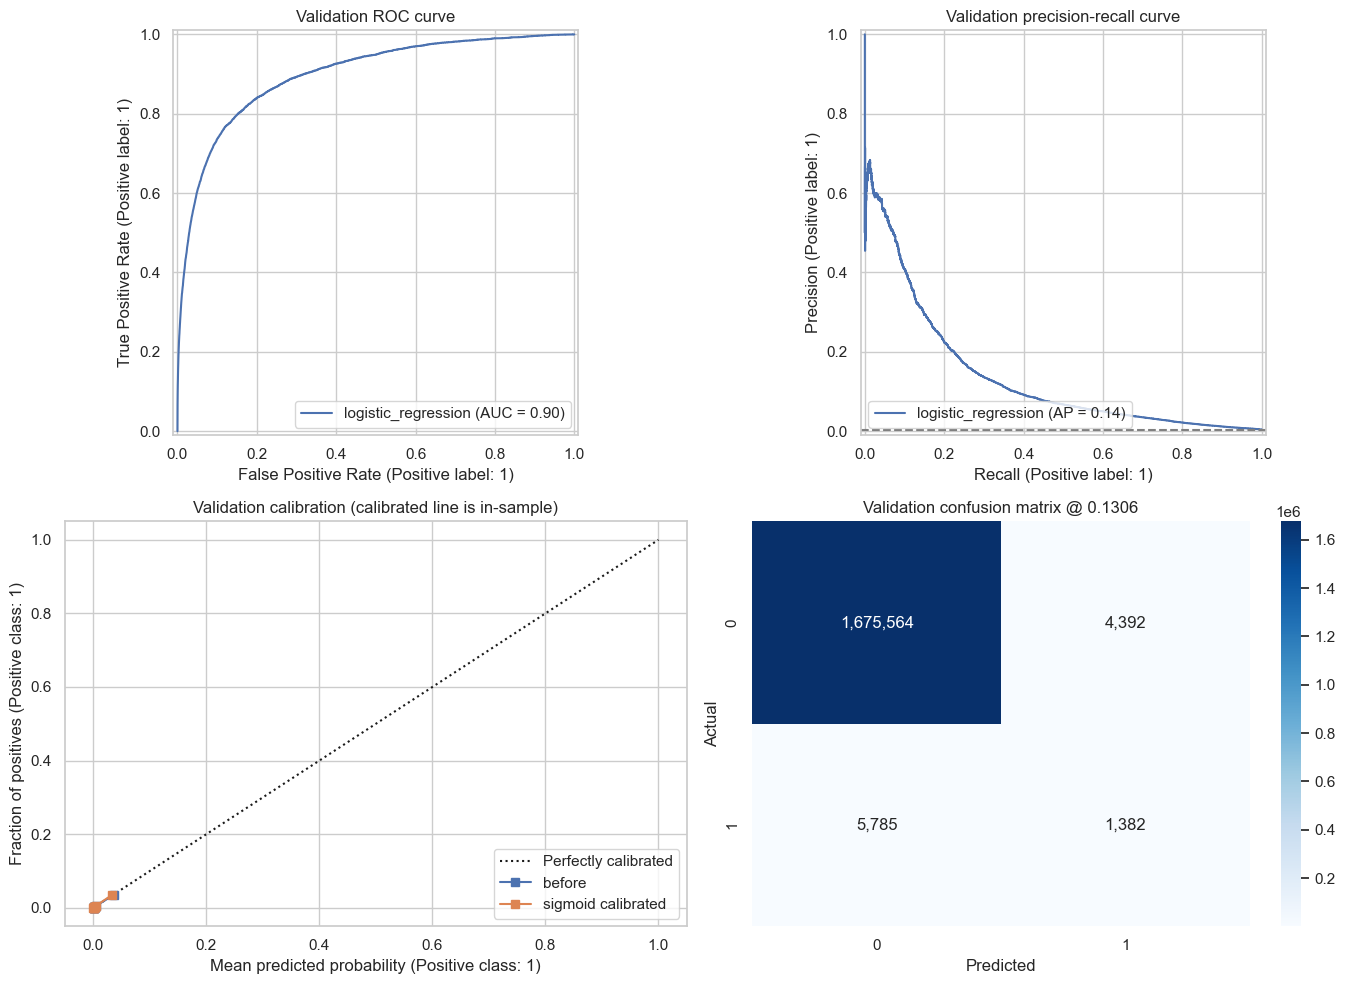

In [8]:
best_model_name = validation_results.index[0]
best_base_model = fitted_models[best_model_name]
best_validation_probability = validation_probabilities[best_model_name]

# Sigmoid calibration is stable at this scale and preserves ranking order.
calibrated_model = CalibratedClassifierCV(FrozenEstimator(best_base_model), method="sigmoid")
calibrated_model.fit(X_validation, y_validation)
calibrated_validation_probability = calibrated_model.predict_proba(X_validation)[:, 1]

# Select a threshold from calibrated validation probabilities. It is for binary
# diagnostics only; Top-10 ranking uses the continuous purchase probability.
precision, recall, thresholds = precision_recall_curve(y_validation, calibrated_validation_probability)
f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
best_threshold = float(thresholds[np.nanargmax(f1)])

print(f"Selected model: {best_model_name}")
print(f"Validation-selected calibrated binary threshold: {best_threshold:.6f}")
print("Validation metrics before calibration:", probability_metrics(y_validation, best_validation_probability))
print("Validation calibration diagnostics (in-sample):", probability_metrics(y_validation, calibrated_validation_probability))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
RocCurveDisplay.from_predictions(y_validation, best_validation_probability, ax=axes[0, 0], name=best_model_name)
axes[0, 0].set_title("Validation ROC curve")
PrecisionRecallDisplay.from_predictions(y_validation, best_validation_probability, ax=axes[0, 1], name=best_model_name)
axes[0, 1].axhline(y_validation.mean(), color="grey", linestyle="--", label="positive rate")
axes[0, 1].set_title("Validation precision-recall curve")
CalibrationDisplay.from_predictions(y_validation, best_validation_probability, n_bins=12, strategy="quantile", ax=axes[1, 0], name="before")
CalibrationDisplay.from_predictions(y_validation, calibrated_validation_probability, n_bins=12, strategy="quantile", ax=axes[1, 0], name="sigmoid calibrated")
axes[1, 0].set_title("Validation calibration (calibrated line is in-sample)")
cm = confusion_matrix(y_validation, calibrated_validation_probability >= best_threshold)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=axes[1, 1])
axes[1, 1].set(title=f"Validation confusion matrix @ {best_threshold:.4f}", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.show()

In [9]:
model_bundle = {
    "estimator": calibrated_model,
    "base_estimator": best_base_model,
    "model_name": best_model_name,
    "feature_columns": FEATURE_COLUMNS,
    "classification_threshold": best_threshold,
    "lookback_days": LOOKBACK_DAYS,
    "candidate_days": CANDIDATE_DAYS,
    "label_horizon_days": HORIZON_DAYS,
    "selection_rule": "highest validation NDCG@10, then PR-AUC",
    "validation_results": validation_results.reset_index().to_dict(orient="records"),
}
MODEL_PATH = MODEL_DIR / "DiscountMate_REES46_purchase_probability_model.joblib"
joblib.dump(model_bundle, MODEL_PATH, compress=3)

metadata = {k: v for k, v in model_bundle.items() if k not in {"estimator", "base_estimator"}}
(MODEL_DIR / "DiscountMate_REES46_purchase_probability_model_metadata.json").write_text(
    json.dumps(metadata, indent=2, default=float), encoding="utf-8"
)
print(f"Exported {MODEL_PATH} ({MODEL_PATH.stat().st_size/1024**2:.1f} MiB)")

Exported /Users/ethan/Desktop/Applied_AI/2026_T2/SIT782/DiscountMate/models/DiscountMate_REES46_purchase_probability_model.joblib (0.0 MiB)


## Section 3 — Final untouched test evaluation and Top-10 output

This section loads the exported bundle and evaluates it once on the chronologically last snapshot. Probabilities—not binary predictions—are the homepage ranking confidence. The binary threshold is included only for diagnostics.

In [10]:
loaded_bundle = joblib.load(MODEL_PATH)
test_frame = pl.read_parquet(FEATURE_FILES["test"])
X_test = test_frame.select(loaded_bundle["feature_columns"]).to_pandas()
y_test = test_frame[TARGET].to_numpy()
test_probability = loaded_bundle["estimator"].predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= loaded_bundle["classification_threshold"]).astype("int8")

test_metrics = probability_metrics(y_test, test_probability)
test_metrics.update(ranking_metrics(test_frame, test_probability, GROUND_TRUTH["test"], k=10))
test_metrics["threshold_from_validation"] = loaded_bundle["classification_threshold"]
test_metrics_table = pd.DataFrame([test_metrics], index=["test"])
display(test_metrics_table.round(6))
print(classification_report(y_test, test_prediction, digits=4, zero_division=0))

,PR_AUC,ROC_AUC,Log_Loss,Brier,CandidatePairCoverage,CandidateUserCoverage,Recall@10,ConditionalCandidateRecall@10,Precision@10,HitRate@10,NDCG@10,evaluated_future_users,threshold_from_validation
test,0.130123,0.897685,0.018492,0.00349,0.117125,0.133636,0.113475,0.968838,0.004663,0.131073,0.099971,40588,0.130622


              precision    recall  f1-score   support

           0     0.9969    0.9977    0.9973   1593478
           1     0.2307    0.1795    0.2019      6033

    accuracy                         0.9946   1599511
   macro avg     0.6138    0.5886    0.5996   1599511
weighted avg     0.9940    0.9946    0.9943   1599511



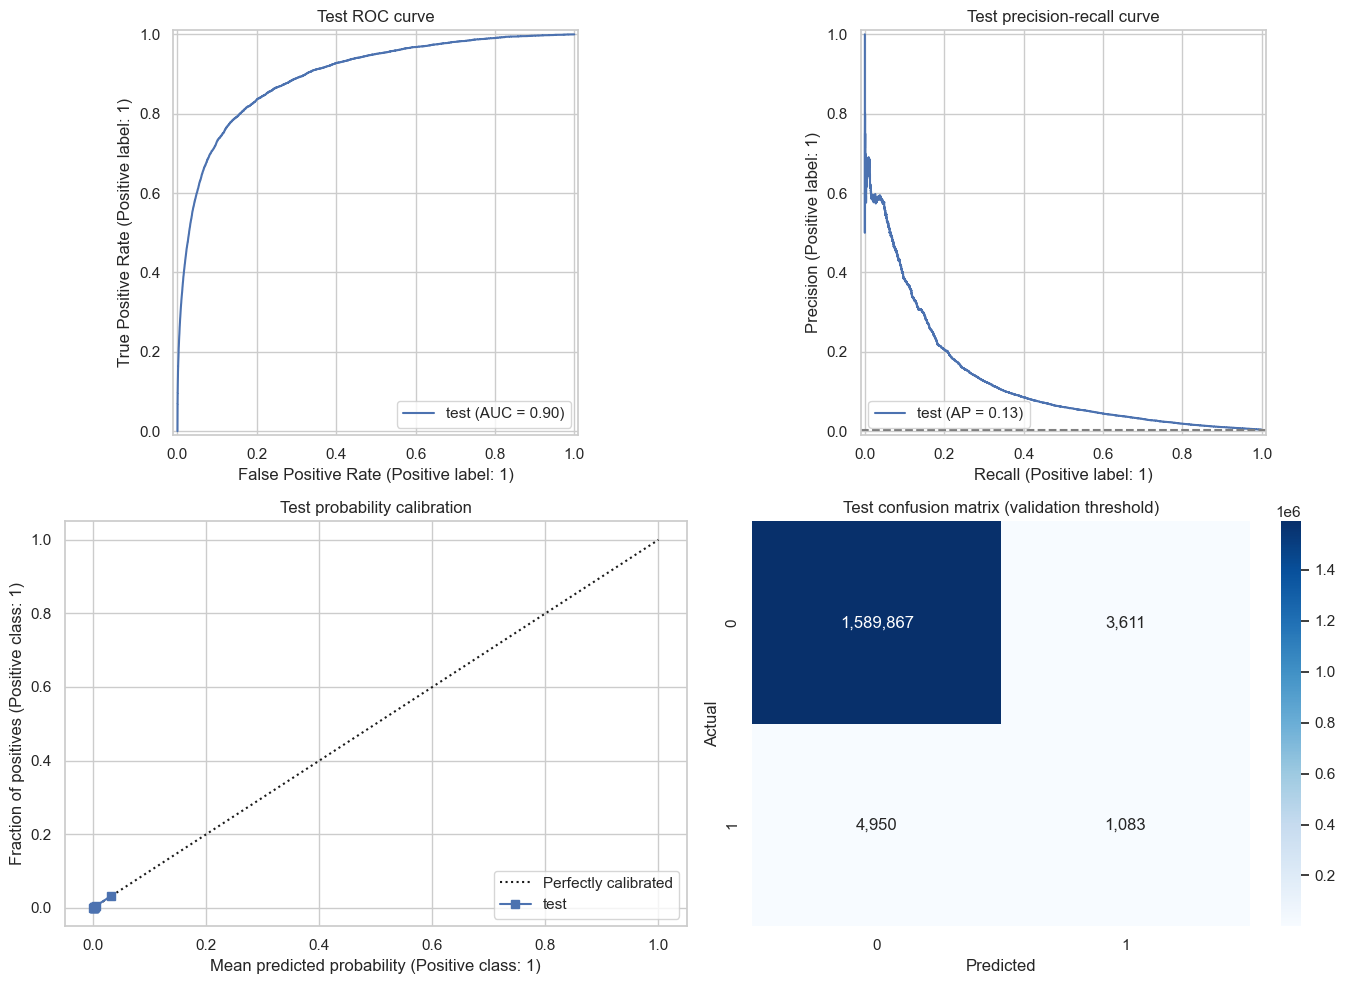

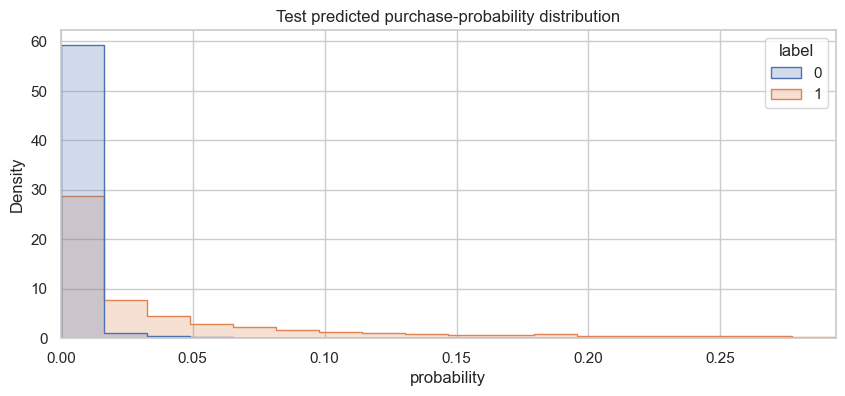

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
RocCurveDisplay.from_predictions(y_test, test_probability, ax=axes[0, 0], name="test")
axes[0, 0].set_title("Test ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, test_probability, ax=axes[0, 1], name="test")
axes[0, 1].axhline(y_test.mean(), color="grey", linestyle="--", label="positive rate")
axes[0, 1].set_title("Test precision-recall curve")
CalibrationDisplay.from_predictions(y_test, test_probability, n_bins=12, strategy="quantile", ax=axes[1, 0], name="test")
axes[1, 0].set_title("Test probability calibration")
cm = confusion_matrix(y_test, test_prediction)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=axes[1, 1])
axes[1, 1].set(title="Test confusion matrix (validation threshold)", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plot_sample = pd.DataFrame({"probability": test_probability, "label": y_test})
sns.histplot(data=plot_sample, x="probability", hue="label", bins=60, stat="density", common_norm=False, element="step")
plt.title("Test predicted purchase-probability distribution")
plt.xlim(0, min(1, np.quantile(test_probability, 0.999) * 1.1))
plt.show()

In [12]:
# Production pattern: score candidates, rank within each user, and take Top 10.
scored_test = test_frame.select("user_id", "product_id", "label", "price").with_columns(
    pl.Series("purchase_probability", test_probability)
)
top_10 = (
    scored_test.sort(["user_id", "purchase_probability", "product_id"], descending=[False, True, False])
    .group_by("user_id", maintain_order=True).head(10)
)

# Show one illustrative user who has a future purchase among the candidate set.
example_user = (
    scored_test.group_by("user_id").agg(pl.col("label").sum().alias("purchases"), pl.len().alias("candidates"))
    .filter((pl.col("purchases") > 0) & (pl.col("candidates") >= 10))
    .sort(["purchases", "candidates"], descending=True)
    .select("user_id").item(0, 0)
)
display(top_10.filter(pl.col("user_id") == example_user).to_pandas())
print(f"Example user: {example_user}; the homepage should use purchase_probability as confidence and rank descending.")

,user_id,product_id,label,price,purchase_probability
0,561174161,1004767,1,243.750000,0.758248
1,561174161,1004750,1,195.259995,0.457317
2,561174161,1004856,1,130.990005,0.378198
3,561174161,1004870,0,278.929993,0.283392
4,561174161,1005100,1,140.449997,0.208767
5,561174161,1005031,0,187.649994,0.206721
6,561174161,1002540,0,462.049988,0.175704
7,561174161,1004833,1,170.139999,0.135228
8,561174161,1004249,1,725.080017,0.122632
9,561174161,1004741,0,189.970001,0.120032


Example user: 561174161; the homepage should use purchase_probability as confidence and rank descending.


### Deployment note

At inference time, reproduce the same 7-day feature definitions at the scoring cutoff, restrict candidates to user-product pairs active in the last 2 days, call `predict_proba`, then rank by `purchase_probability` within each user and keep 10. A broader candidate generator (for example collaborative filtering or popular unseen products) can later be added before this probability-ranking stage; offline metrics in this notebook only measure purchases within the event-derived candidate set.